In [3]:
'''
금융 AI 포트폴리오를 만들것임. 

그러기 위해 첫번째로 **데이터 수집** 을 먼저 수행함. 

우선, 삼성전자의 과거 주가 데이터를 파이썬으로 직접 불러오겠다. 
'''

import FinanceDataReader as fdr
import pandas as pd

# 1. 삼성전자(종목코드:005930)의 2023년부터 현재까지의 데이터를 가져온다. 
# 종목코드는 6자리 숫자로 된 문자열을 입력해야 함. 
symbol = '005930'
df = fdr.DataReader(symbol, '2023-01-01')

# 2. 데이터가 잘 들어왔는지 상위 5줄만 확인해봄. 
print("--- 삼성전자 주가 데이터 상위 5행 ---")
print(df.head())

# 3. 데이터의 전반적인 정보를 확인. (데이터 개수, 컬럼 타입 등)
print("\n --- 데이터 정보 확인 ---")
df.info()

'''
Open : 시가
High : 고가
Low : 저가
Close : 종가 - 분석할때 보통 많이 사용함. 
Volume : 거래량 - 얼마나 많이 사고팔았는지
Change : 대비 - 전날 대비 등락률
'''

# 4. 수집한 데이터를 csv 파일로 저장해둔다. (나중에 불러오기 편하게)
df.to_csv('samsung_stock_2023_2024.csv')
print("\n 파일 저장이 완료되었습니다: samsung_stock_2023_2024.csv")

--- 삼성전자 주가 데이터 상위 5행 ---
             Open   High    Low  Close    Volume    Change
Date                                                      
2023-01-02  55500  56100  55200  55500  10031448  0.003617
2023-01-03  55400  56000  54500  55400  13547030 -0.001802
2023-01-04  55700  58000  55600  57800  20188071  0.043321
2023-01-05  58200  58800  57600  58200  15682826  0.006920
2023-01-06  58300  59400  57900  59000  17334989  0.013746

 --- 데이터 정보 확인 ---
<class 'pandas.DataFrame'>
DatetimeIndex: 769 entries, 2023-01-02 to 2026-02-27
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    769 non-null    int64  
 1   High    769 non-null    int64  
 2   Low     769 non-null    int64  
 3   Close   769 non-null    int64  
 4   Volume  769 non-null    int64  
 5   Change  769 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 42.1 KB

 파일 저장이 완료되었습니다: samsung_stock_2023_2024.csv


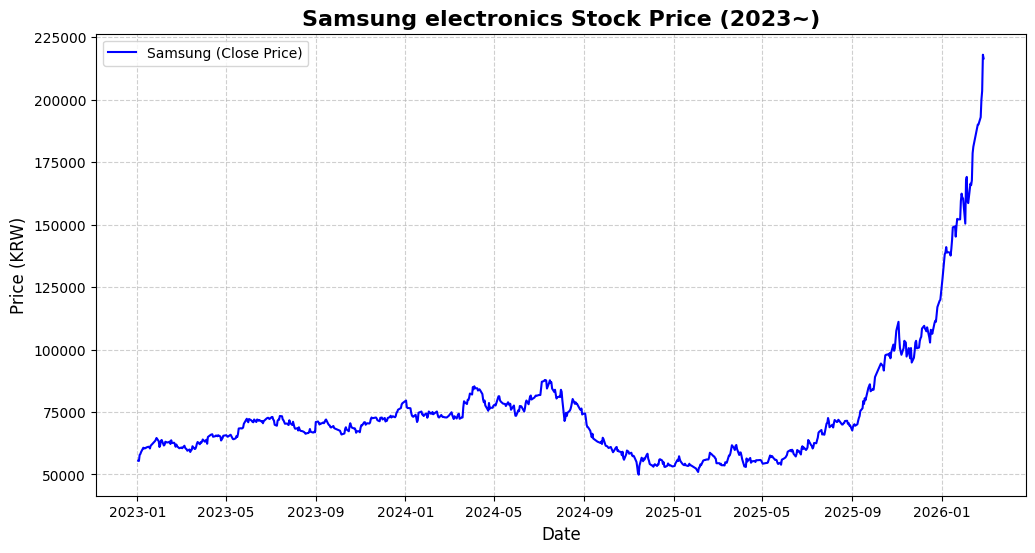

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 아까 저장해둔 csv 파일을 불러온다. 
# parse_dates = True를 하면 'Data' 컬럼을 단순한 글자가 아닌 '날짜' 형식으로 똑똑하게 인식한다. 
df = pd.read_csv('samsung_stock_2023_2024.csv', index_col='Date', parse_dates=True)

# 2. 도화지(그래프 창)의 크기를 설정한다 (가로12 세로6)
plt.figure(figsize=(12,6))

# 3. 꺾은선 그래프 그리기
# x축은 날짜, y축은 종가로 설정한다. 
plt.plot(df.index, df['Close'], label='Samsung (Close Price)', color='blue', linewidth=1.5)

# 4. 그래프 예쁘게 꾸미기
plt.title('Samsung electronics Stock Price (2023~)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (KRW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. 완성된 그래프 출력
plt.show()

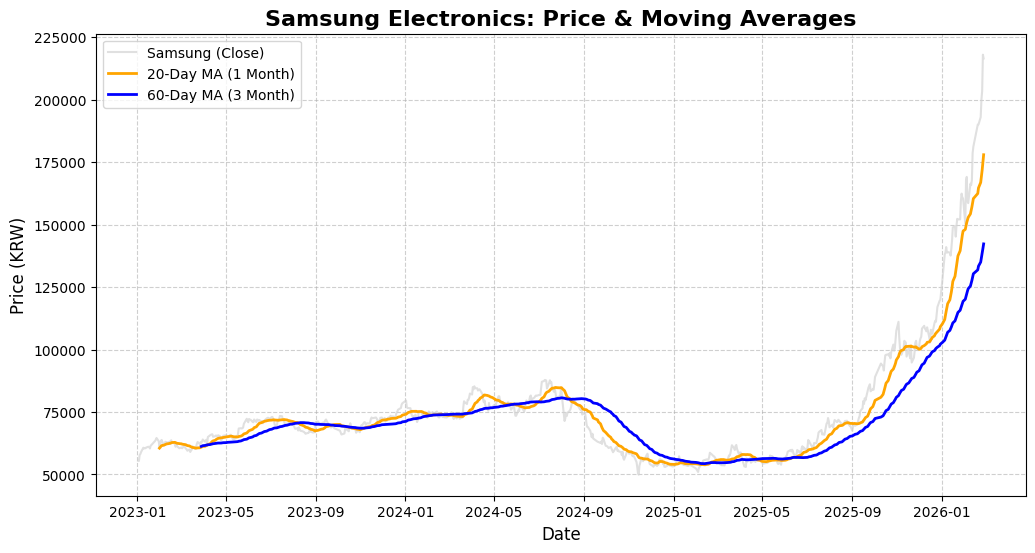

In [2]:
# 1. 이동평균선 데이터 만들기 (Pandas의 rolling 함수를 이용하면 아주 쉽다.)
# window=20은 '최근 20일 치 데이터를 묶어서' 라는 뜻이고, mean()은 '평균을 내라'는 뜻임. 
# rolling 함수 : 
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

# 2. 도화지 크기 설정
plt.figure(figsize=(12,6))

# 3. 선 그리기
# 원래 주가(종가)는 배경처럼 연하게 깔아준다. 
plt.plot(df.index, df['Close'], label='Samsung (Close)', color='lightgray', linewidth=1.5, alpha=0.7)

# 이동평균선을 눈에 띄게 그려준다. 
plt.plot(df.index, df['MA20'], label='20-Day MA (1 Month)', color='orange', linewidth=2)
plt.plot(df.index, df['MA60'], label='60-Day MA (3 Month)', color='blue', linewidth=2)

# 4. 그래프 꾸미기
plt.title('Samsung Electronics: Price & Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (KRW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. 출력
plt.show()

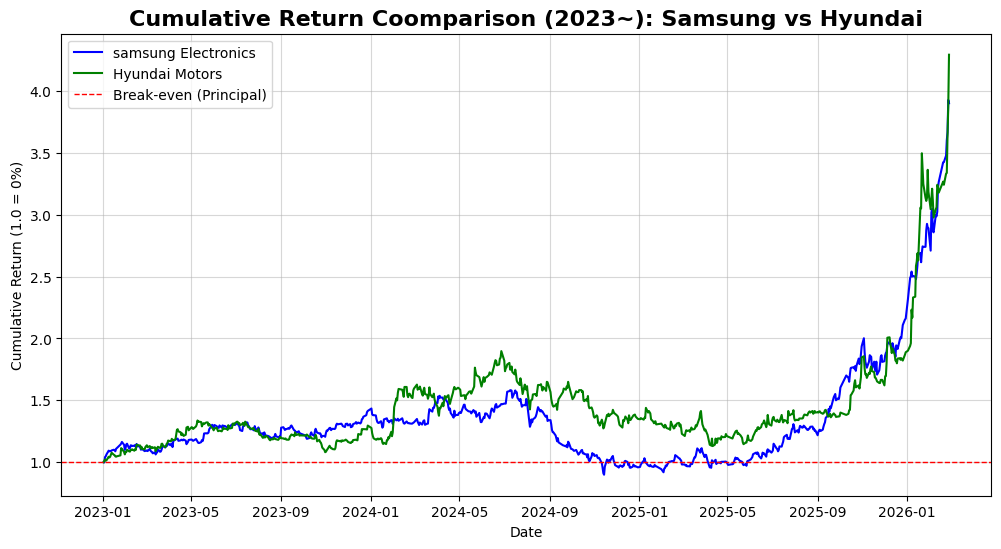

In [6]:
# 삼성전자vs 현대차, 누가 더 많이 올랐을까

import FinanceDataReader as fdr
import matplotlib.pyplot as plt

# 1. 두 종목 데이터 한 번에 가져오기
# 삼성전자(005930), 현대차(005380)

df_samsung = fdr.DataReader('005930', '2023-01-01')
df_hyundai = fdr.DataReader('005380', '2023-01-01')

# 2. 수익률 계산하기 (가장 핵심)
# 첫 날의 종가로 매일의 종가를 나누면, 첫날을 1로 기준잡은 누적 수익률이 나옴. 
samsung_return = df_samsung['Close'] / df_samsung['Close'].iloc[0]
hyundai_return = df_hyundai['Close'] / df_hyundai['Close'].iloc[0]

# 3. 도화지 세팅 및 그래프 그리기
plt.figure(figsize=(12,6))

# 수익률 선 그리기
plt.plot(samsung_return.index, samsung_return, label='samsung Electronics', color='blue')
plt.plot(hyundai_return.index, hyundai_return, label='Hyundai Motors', color='green')

# 4. 기준선(원금, 1.0) 긋기
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Break-even (Principal)')

# 5. 그래프 꾸미기
plt.title('Cumulative Return Coomparison (2023~): Samsung vs Hyundai', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = 0%)')
plt.grid(True, alpha=0.5)
plt.legend()

plt.show()

In [4]:
import requests
from bs4 import BeautifulSoup

# 1. 타겟 웹사이트 주소(삼성전자 005930 네이터 금융 뉴스 iframe 주소)
url = "https://finance.naver.com/item/news_news.naver?code=005930"

# 2. 브라우저인 척 위장하기 (User-Agent)
# 웹사이트가 봇이라고 차단하는것을 막기 위해 신분증 제시하는 과정. 
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

# 3. requests로 웹페이지(HTML) 뼈대 통째로 가져오기 (배달부)
response = requests.get(url, headers=headers)

# 디버깅 1: 네이버가 우리 봇을 차단했는지
print(f"웹 사이트 접속 상태 코드: {response.status_code}\n")

# 4. bs4로 HTML 요리하기 (요리사)
# 'html.parser'라는 칼을 써서 가져온 텍스트를 파이썬이 다루기 쉬운 형태로 변환
# 디버깅 2: 한글 깨짐 방지로 text 대신 content 사용
soup = BeautifulSoup(response.content, 'html.parser')

# 5. 뉴스 제목만 쏙쏙 골라내기
# 네이버 금융 뉴스 제목들은 보통 class="tit" 라는 이름표를 단 <a> 태그 안에 들어있음.
# 디버깅 3: 이름표가 바뀌었을 테니 네이버가 뉴스에 자주 쓰는 이름표를 싹 다 던져보기
titles = soup.select('.title a, .articleSubject, .news_tit, .tit')

# 6. 상위 10개 기사 제목 깔끔하게 출력하기
print("--- 삼성전자 최신뉴스 TOP 10 ---")
if not titles:
    print("title 목록 없음")
else:
    for i, title in enumerate(titles[:10]):
        # .get_text로 태그<a...>는 버리고 알맹이 텍스트만 가져오고, .strip()으로 양옆 공백 제거
        clean_title = title.get_text().strip()
        print(f"{i+1}. {clean_title}")

웹 사이트 접속 상태 코드: 200

--- 삼성전자 최신뉴스 TOP 10 ---
title 목록 없음


In [9]:
import requests
from bs4 import BeautifulSoup

# 1. 타겟 주소 (삼성전자 뉴스 검색)
url = "https://search.naver.com/search.naver?where=news&query=삼성전자"

# 2. 브라우저 위장
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

# 3. 데이터 가져오기 및 요리 준비
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# 4. 네가 찾아낸 정확한 이름표 적용!
# span 태그 중에서 클래스 이름이 'sds-comps-text-type-headline1'인 녀석들만 싹 다 찾아와!
titles = soup.select('span.sds-comps-text-type-headline1')

# 5. 깔끔하게 텍스트만 뽑아서 출력
print("--- 📈 삼성전자 최신 뉴스 TOP 10 ---")

if titles:
    for i, title in enumerate(titles[:10]):
        # get_text()가 <mark> 태그까지 알아서 무시하고 글자만 쏙 빼줍니다.
        clean_title = title.get_text().strip()
        print(f"{i+1}. {clean_title}")
else:
    print("🚨 앗, 아직도 못 찾았어요. 코드를 다시 확인해 주세요.")

--- 📈 삼성전자 최신 뉴스 TOP 10 ---
1. 삼성전자 장중 7%↓…코스피 매도 사이드카 발동
2. 침착맨 "7만원에 팔았던 삼성전자, 21만원에 다시 샀다"
3. 삼성, '갤럭시 AI' 생태계 전반으로 연결성 확장[MWC26]
4. 21조 던진 외국인, 삼성전자·하이닉스 팔고 소부장으로 이동
5. 갤S26은 광장에, XR·버즈4는 밀실에…삼성전자 내·외부 '인산인해'
6. '검은 화요일' 코스피, 결국 5,800선 내줘…삼성전자·SK하이닉스도 급락
7. 외국인, 삼전닉스 4.4조 '매도 폭탄'… 방산·정유株는 급등
8. 길어진 무더위 대비… 삼성전자, ‘AI 기술’ 접목 에어컨 점검지원
9. 삼성전자, 에어컨 사전점검 실시
10. SK하이닉스 15.5%↓ 삼성전자 14.1%↓…애프터마켓서 하락폭 커져


In [13]:
import pandas as pd

# 1. 뉴스 제목을 담을 리스트 준비
news_list = []

# 2. 추출한 제목들을 바구니에 담기
for title in titles[:10]:
    clean_title = title.get_text().strip()
    news_list.append(clean_title)

# 3. 바구니에 담긴 데이터를 DataFrame로 변환
df_news = pd.DataFrame(news_list, columns=['Title'])

# 4. 내 컴퓨터에 csv로 저장
# utf-8-sig를 넣어야 엑셀로 열었을 때 한글이 외계어로 안깨짐
df_news.to_csv('samsung_news.csv', index=False, encoding='utf-8-sig')

print('samsung_news.csv 저장 완료')

# 5. 주피터 화면에서 head 출력
df_news.head()

samsung_news.csv 저장 완료


,Title
0,삼성전자 장중 7%↓…코스피 매도 사이드카 발동
1,"침착맨 ""7만원에 팔았던 삼성전자, 21만원에 다시 샀다"""
2,"삼성, '갤럭시 AI' 생태계 전반으로 연결성 확장[MWC26]"
3,"21조 던진 외국인, 삼성전자·하이닉스 팔고 소부장으로 이동"
4,"갤S26은 광장에, XR·버즈4는 밀실에…삼성전자 내·외부 '인산인해'"
